# Customer Shopping Behavior and Trends Analysis

**Exploratory Data Analysis (EDA) and Data Visualization on Retail Consumer Data**

**Notebook sections:**
1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Visualization Dashboard
5. Discount & Promo Code Impact Analysis
6. Key Insights & Business Recommendations


## 1. Setup & Data Loading

Import the required libraries and load the raw dataset. We use `pandas`/`numpy` for data manipulation and `matplotlib`/`seaborn` for visualization.


In [41]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display & plotting settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'


#Displays graph in the notebook
%matplotlib inline 


In [42]:
# Load the dataset
# The first (unnamed) column in the CSV is a row index, so we drop it on load
df = pd.read_csv('Shopping Trends And Customer Behaviour Dataset.csv', index_col=0)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 3900 rows x 17 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [43]:
# Quick look at column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           3900 non-null   float64
 10  Subscription Status     3900 non-null   str    
 11  Shipping Type           3900 non-null   str    
 12  Discount Applied        3900 non-null   str    
 13  Promo Code Used         3900 non-null   str    
 14  Previous Purchases      3900 non-null   int64  
 15

## 2. Data Cleaning & Preprocessing

Before analysis, we check for missing values, duplicate records, and make sure column types are correctly set.


In [44]:
# --- Check for missing values ---
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in any column.")
else:
    print("Missing values per column:")
    print(missing)


No missing values found in any column.


In [45]:
# --- Check for duplicate rows ---
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")

if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows to remove.")


Number of fully duplicated rows: 0
No duplicate rows to remove.


In [46]:
# --- Standardize text columns (strip whitespace, consistent casing) ---
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

print("Standardized categorical columns:")
print(categorical_cols)
# Identify all text-based columns and remove any leading or trailing whitespace from their entries

Standardized categorical columns:
['Gender', 'Item Purchased', 'Category', 'Location', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


In [47]:
# --- Confirm/enforce sensible dtypes ---
# Numeric columns
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Binary Yes/No columns -> keep as categorical strings, but useful to have boolean flags too
df['Discount Applied Flag'] = df['Discount Applied'].map({'Yes': 1, 'No': 0})
df['Promo Code Used Flag'] = df['Promo Code Used'].map({'Yes': 1, 'No': 0})
df['Subscriber Flag'] = df['Subscription Status'].map({'Yes': 1, 'No': 0})

df.dtypes


Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
Discount Applied Flag       int64
Promo Code Used Flag        int64
Subscriber Flag             int64
dtype: object

In [48]:
# --- Create an Age Group column for easier demographic analysis ---
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age', 'Age Group']].head()


,Age,Age Group
0,55,46-55
1,19,18-25
2,50,46-55
3,21,18-25
4,45,36-45


In [49]:
# --- Final sanity check after cleaning ---
print(f"Final cleaned dataset shape: {df.shape}")
df.describe(include='all').T


Final cleaned dataset shape: (3900, 21)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Rating,3900.0,NaN,NaN,NaN,3.749949,0.716223,2.5,3.1,3.7,4.4,5.0


## 3. Exploratory Data Analysis (EDA)

Here we analyze spending distributions across age groups, gender, and product categories, and look at behavioral factors such as subscription status, payment method, and purchase frequency.


### 3.1 Summary Statistics

In [50]:
# Summary statistics for numeric fields
df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].describe()


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


### 3.2 Gender Distribution

In [51]:
gender_counts = df['Gender'].value_counts()
gender_pct = (gender_counts / gender_counts.sum() * 100).round(1)

print("Customer count by gender:")
print(gender_counts)
print("\nPercentage share:")
print(gender_pct)


Customer count by gender:
Gender
Male      2652
Female    1248
Name: count, dtype: int64

Percentage share:
Gender
Male      68.0
Female    32.0
Name: count, dtype: float64


### 3.3 Spending by Age Group and Gender

In [52]:
# Average purchase amount by age group
age_spend = df.groupby('Age Group', observed=True)['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
age_spend


,mean,median,count
Age Group,,,
18-25,60.65,62.0,571
26-35,59.76,60.0,742
36-45,59.31,59.0,729
46-55,60.58,62.0,753
56-65,59.14,58.5,750
66+,58.88,59.0,355


In [53]:
# Average purchase amount by gender
gender_spend = df.groupby('Gender')['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
gender_spend


,mean,median,count
Gender,,,
Female,60.25,60.0,1248
Male,59.54,60.0,2652


### 3.4 Category & Item Popularity

In [54]:
# Top product categories by number of purchases and total revenue
category_summary = df.groupby('Category').agg(
    Purchases=('Category', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean')
).sort_values('Total_Revenue', ascending=False).round(2)

category_summary


,Purchases,Total_Revenue,Avg_Spend
Category,,,
Clothing,1737,104264,60.03
Accessories,1240,74200,59.84
Footwear,599,36093,60.26
Outerwear,324,18524,57.17


In [55]:
# Top 10 most purchased items overall
top_items = df['Item Purchased'].value_counts().head(10)
top_items


Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64

### 3.5 Seasonal Trends

In [56]:
season_summary = df.groupby('Season').agg(
    Purchases=('Season', 'count'),
    Total_Revenue=('Purchase Amount (USD)', 'sum'),
    Avg_Spend=('Purchase Amount (USD)', 'mean')
).round(2)

season_summary


,Purchases,Total_Revenue,Avg_Spend
Season,,,
Fall,975,60018,61.56
Spring,999,58679,58.74
Summer,955,55777,58.41
Winter,971,58607,60.36


### 3.6 Behavioral Factors: Payment Method, Shipping Type, Purchase Frequency

In [57]:
payment_counts = df['Payment Method'].value_counts()
shipping_counts = df['Shipping Type'].value_counts()
frequency_counts = df['Frequency of Purchases'].value_counts()

print("Payment Method distribution:\n", payment_counts, "\n")
print("Shipping Type distribution:\n", shipping_counts, "\n")
print("Frequency of Purchases distribution:\n", frequency_counts)


Payment Method distribution:
 Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64 

Shipping Type distribution:
 Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64 

Frequency of Purchases distribution:
 Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


## 4. Visualization Dashboard

A set of charts (distribution plots, category breakdowns, and a correlation heatmap) that communicate the core insights visually.


### 4.1 Age Distribution

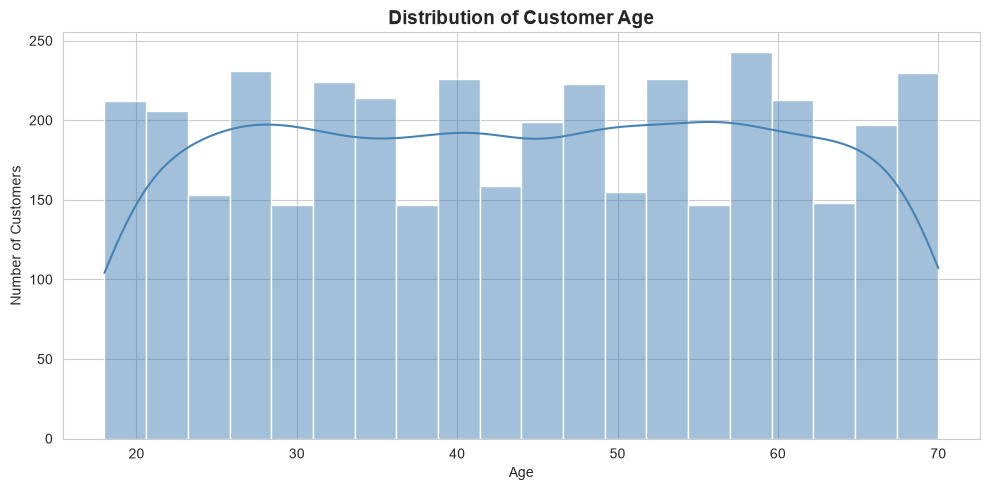

In [58]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### 4.2 Purchase Amount Distribution

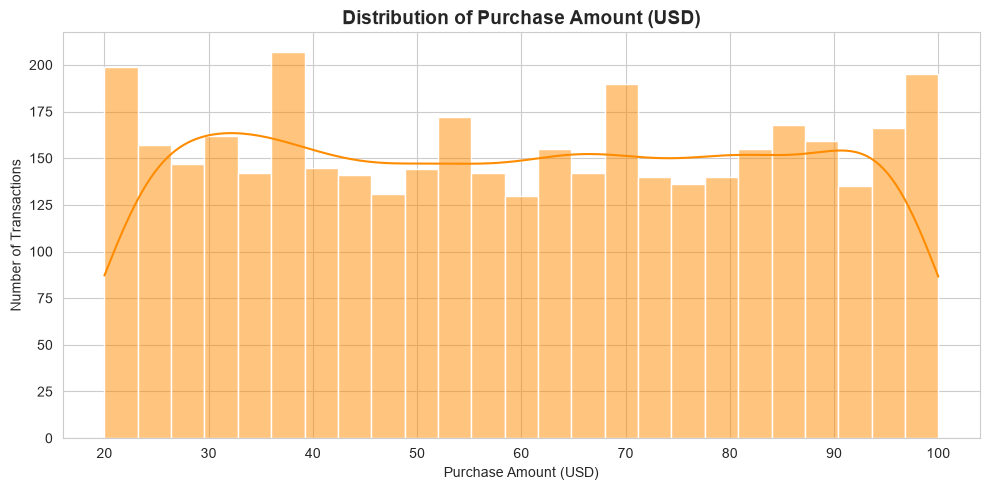

In [59]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=25, kde=True, color='darkorange')
plt.title('Distribution of Purchase Amount (USD)')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


### 4.3 Average Spend by Age Group and Gender

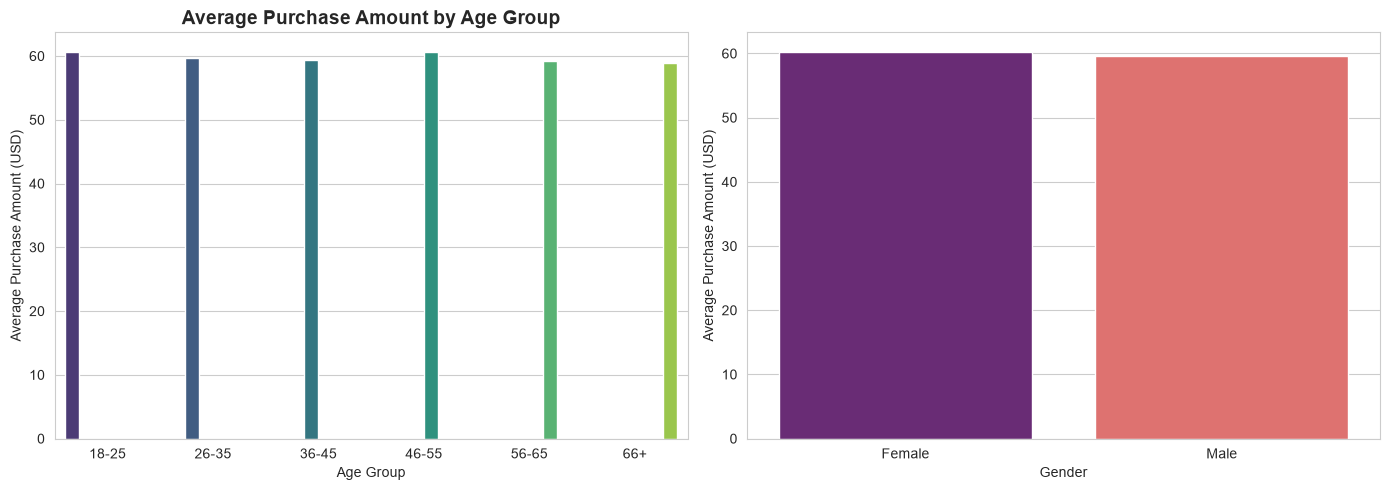

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=age_spend.index, y=age_spend['mean'], ax=axes[0], hue=age_spend.index, legend=False, palette='viridis')
axes[0].set_title('Average Purchase Amount by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Purchase Amount (USD)')

sns.barplot(x=gender_spend.index, y=gender_spend['mean'], ax=axes[1], hue=gender_spend.index, legend=False, palette='magma')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Average Purchase Amount (USD)')

plt.tight_layout()
plt.show()


### 4.4 Category Breakdown

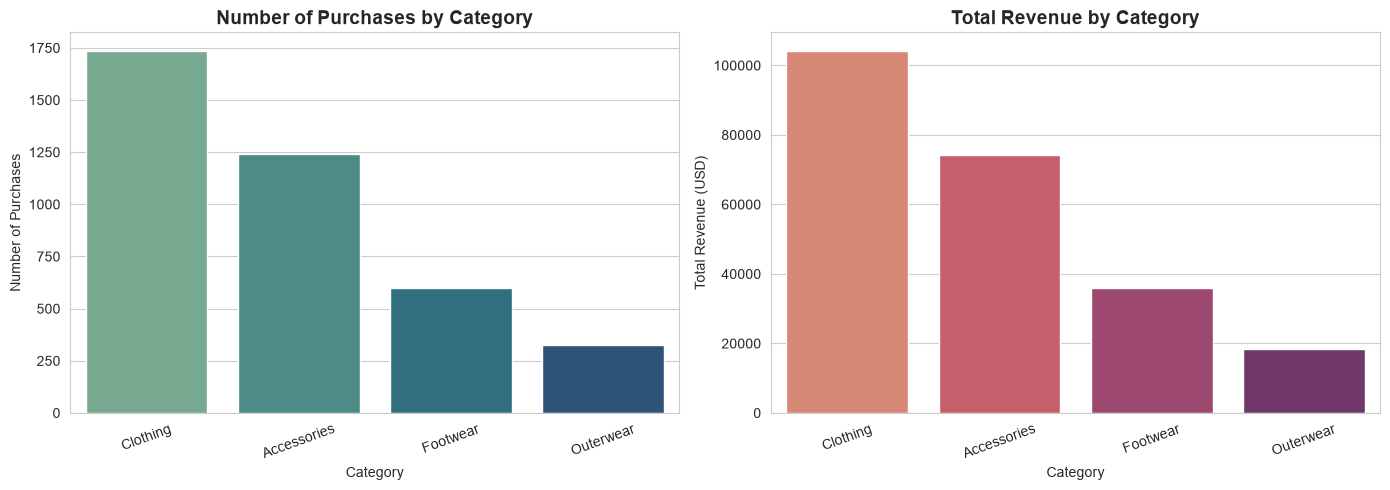

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=category_summary.index, y=category_summary['Purchases'], ax=axes[0], hue=category_summary.index, legend=False, palette='crest')
axes[0].set_title('Number of Purchases by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Purchases')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=category_summary.index, y=category_summary['Total_Revenue'], ax=axes[1], hue=category_summary.index, legend=False, palette='flare')
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### 4.5 Seasonal Purchase Trends

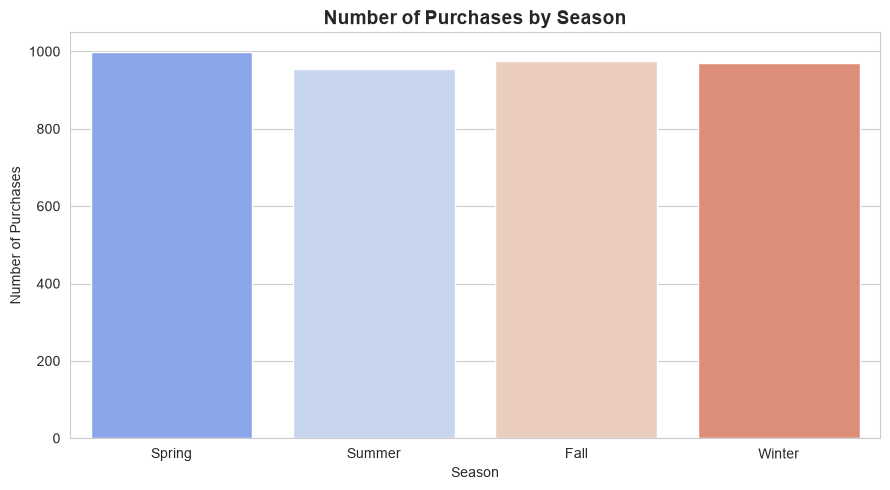

In [62]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_summary_ordered = season_summary.reindex(season_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=season_summary_ordered.index, y=season_summary_ordered['Purchases'], hue=season_summary_ordered.index, legend=False, palette='coolwarm')
plt.title('Number of Purchases by Season')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.tight_layout()
plt.show()


### 4.6 Payment Method & Shipping Type Preferences

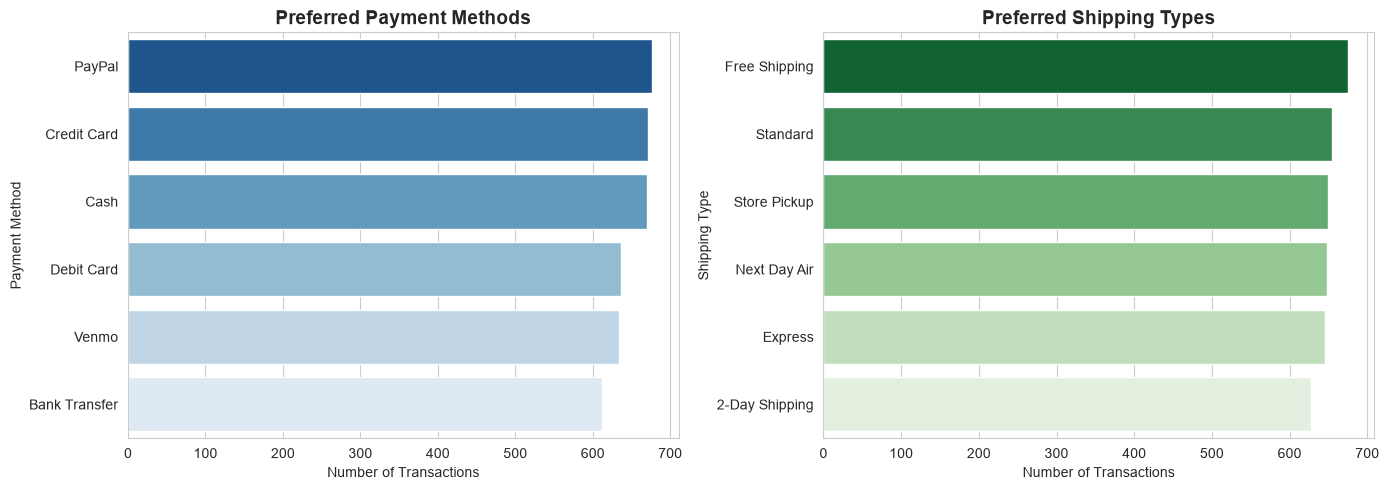

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=payment_counts.values, y=payment_counts.index, ax=axes[0], hue=payment_counts.index, legend=False, palette='Blues_r')
axes[0].set_title('Preferred Payment Methods')
axes[0].set_xlabel('Number of Transactions')

sns.barplot(x=shipping_counts.values, y=shipping_counts.index, ax=axes[1], hue=shipping_counts.index, legend=False, palette='Greens_r')
axes[1].set_title('Preferred Shipping Types')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()


### 4.7 Correlation Heatmap (Numeric Features)

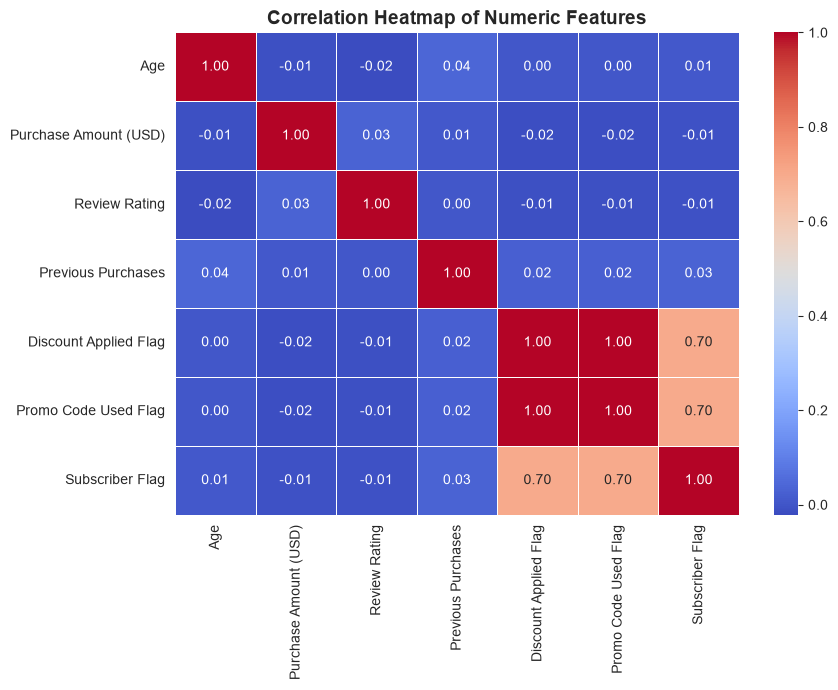

In [64]:
numeric_for_corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating',
                        'Previous Purchases', 'Discount Applied Flag',
                        'Promo Code Used Flag', 'Subscriber Flag']]

corr = numeric_for_corr.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


## 5. Discount & Promo Code Impact Analysis

This section specifically examines how discounts and promotional codes influence consumer spending amounts and behavior, as called out in the project objectives.


### 5.1 Spending: Discount vs No Discount

In [65]:
discount_spend = df.groupby('Discount Applied')['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
discount_spend


,mean,median,count
Discount Applied,,,
No,60.13,60.0,2223
Yes,59.28,60.0,1677


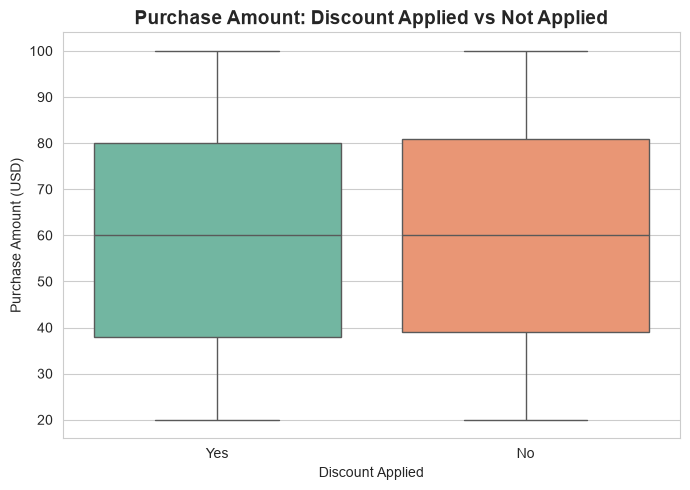

In [66]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Discount Applied', y='Purchase Amount (USD)', data=df, hue='Discount Applied', legend=False, palette='Set2')
plt.title('Purchase Amount: Discount Applied vs Not Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()


### 5.2 Spending: Promo Code Used vs Not Used

In [67]:
promo_spend = df.groupby('Promo Code Used')['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
promo_spend


,mean,median,count
Promo Code Used,,,
No,60.13,60.0,2223
Yes,59.28,60.0,1677


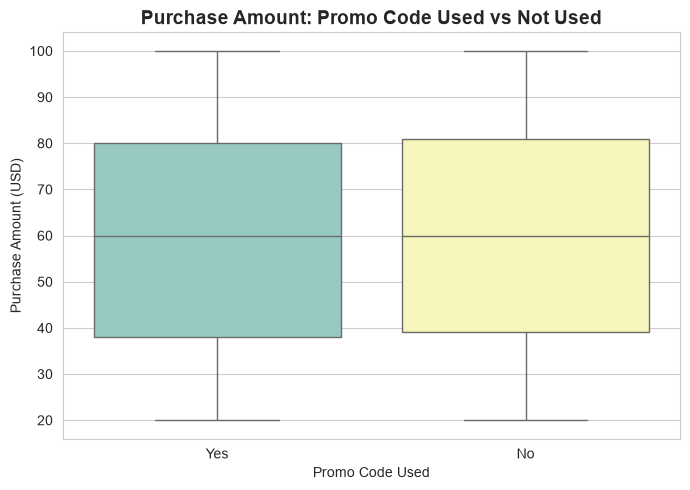

In [68]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Promo Code Used', y='Purchase Amount (USD)', data=df, hue='Promo Code Used', legend=False, palette='Set3')
plt.title('Purchase Amount: Promo Code Used vs Not Used')
plt.xlabel('Promo Code Used')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()


### 5.3 Discount Usage by Category and Subscription Status

In [69]:
discount_by_category = pd.crosstab(df['Category'], df['Discount Applied'], normalize='index') * 100
discount_by_category = discount_by_category.round(1)
discount_by_category


Discount Applied,No,Yes
Category,,
Accessories,56.2,43.8
Clothing,57.9,42.1
Footwear,56.8,43.2
Outerwear,55.6,44.4


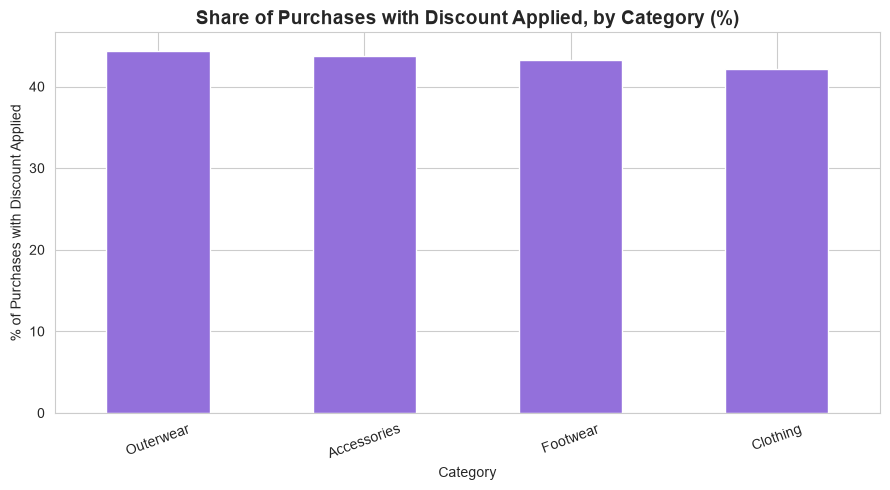

In [70]:
plt.figure(figsize=(9, 5))
discount_by_category['Yes'].sort_values(ascending=False).plot(kind='bar', color='mediumpurple')
plt.title('Share of Purchases with Discount Applied, by Category (%)')
plt.xlabel('Category')
plt.ylabel('% of Purchases with Discount Applied')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [71]:
discount_by_subscription = pd.crosstab(df['Subscription Status'], df['Discount Applied'], normalize='index') * 100
discount_by_subscription = discount_by_subscription.round(1)
discount_by_subscription


Discount Applied,No,Yes
Subscription Status,,
No,78.1,21.9
Yes,0.0,100.0


### 5.4 Statistical Check: Does Discount Usage Correlate with Purchase Amount?

In [72]:
from scipy import stats

discounted = df[df['Discount Applied Flag'] == 1]['Purchase Amount (USD)']
not_discounted = df[df['Discount Applied Flag'] == 0]['Purchase Amount (USD)']

t_stat, p_value = stats.ttest_ind(discounted, not_discounted, equal_var=False)

print(f"Mean spend (Discount Applied):     {discounted.mean():.2f}")
print(f"Mean spend (No Discount Applied):  {not_discounted.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant difference in spending between the two groups (p < 0.05).")
else:
    print("=> No statistically significant difference in spending between the two groups (p >= 0.05).")


Mean spend (Discount Applied):     59.28
Mean spend (No Discount Applied):  60.13
T-statistic: -1.112, p-value: 0.2661
=> No statistically significant difference in spending between the two groups (p >= 0.05).


## 6. Key Insights & Business Recommendations

Based on the EDA and visualizations above, we summarize the core findings and expected outcomes outlined in the project objectives:

- **Top-performing categories & peak seasons:** Identify which product categories drive the most revenue/volume and whether particular seasons see purchase spikes (see Sections 3.4, 3.5, and the corresponding charts in 4.4–4.5).
- **Demographic patterns:** Compare average spend across age groups and gender to understand which segments are the highest-value customers (Sections 3.3, 4.3).
- **Discount & promo code impact:** The boxplots and t-test in Section 5 quantify whether discounted/promo transactions differ meaningfully from full-price transactions in spend amount, and which categories/subscriber segments rely most on discounts.
- **Behavioral preferences:** Payment method, shipping type, and purchase frequency distributions (Sections 3.6, 4.6) can guide operational decisions (e.g., which payment/shipping options to prioritize).

### Suggested next steps for the business
1. Focus marketing spend on the highest-revenue categories and peak season identified above.
2. Tailor discount/promo strategies by category and customer segment based on where they most influence purchase amount.
3. Use age-group and gender spending patterns to refine customer segmentation for targeted campaigns.
4. Monitor subscription status alongside discount usage to evaluate loyalty-program effectiveness.

